# Bandits with Saved Wine Recommenders

This notebook runs bandit policies using **saved recommendation outputs** from your model notebooks.

Expected arms (one per area):
- non-personalized: `popular_global_recs.csv`
- collaborative: `als_recs.csv`
- content-based: one of `content_tfidf_recs.csv`, `content_bow_recs.csv`, `content_lemma_tfidf_recs.csv`, `content_ner_tfidf_recs.csv`, `content_bert_recs.csv`


## 1) Setup

In [60]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


In [61]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'dataset').exists() and (c / 'bandits').exists():
            return c
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
ARMS_DIR = PROJECT_ROOT / 'bandits' / 'saved_arms'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results' / 'bandits'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARMS_DIR:', ARMS_DIR)


PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system
ARMS_DIR: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/bandits/saved_arms


## 2) Load ratings and build test rewards

Bandit reward is binary:
- `1` if chosen item is in user positive test set (`Rating >= 4`)
- `0` otherwise


In [62]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for c in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (c / 'data' / 'results' / 'shared_split').exists():
        PROJECT_ROOT = c
        break

DATASET_DIR = PROJECT_ROOT / 'dataset'
ARMS_DIR = PROJECT_ROOT / 'bandits' / 'saved_arms'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results' / 'bandits'
SPLIT_DIR = PROJECT_ROOT / 'data' / 'results' / 'shared_split'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(
    SPLIT_DIR / 'train_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)
test_df = pd.read_csv(
    SPLIT_DIR / 'test_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

test_relevant = test_df.groupby('UserID')['WineID'].apply(set).to_dict()
shared_users = sorted(test_df['UserID'].unique())

print('Loaded shared split from:', SPLIT_DIR)
print('train:', train_df.shape)
print('test:', test_df.shape)
print('shared users:', len(shared_users))



Loaded shared split from: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/shared_split
train: (56673, 3)
test: (16646, 3)
shared users: 5000


In [63]:
def split_train_test_per_user(df, test_fraction=0.2, random_state=42):
    tr, te = [], []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state)
        n_test = max(1, int(np.ceil(len(g) * test_fraction)))
        te_g, tr_g = g.iloc[:n_test], g.iloc[n_test:]
        if len(tr_g) == 0:
            continue
        tr.append(tr_g)
        te.append(te_g)
    return pd.concat(tr, ignore_index=True), pd.concat(te, ignore_index=True)



## 3) Load saved arm recommendations

Each saved file must have columns:
- `UserID`
- `rank`
- `WineID`


In [64]:
required_files = {
    'popular': ARMS_DIR / 'popular_global_recs.csv',
    'als': ARMS_DIR / 'als_recs.csv',
}

content_candidates = [
    ARMS_DIR / 'content_tfidf_recs.csv',
    ARMS_DIR / 'content_bow_recs.csv',
    ARMS_DIR / 'content_lemma_tfidf_recs.csv',
    ARMS_DIR / 'content_ner_tfidf_recs.csv',
    ARMS_DIR / 'content_bert_recs.csv',
]

missing = [str(p) for p in required_files.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required arm files:\n' + '\n'.join(missing))

content_file = next((p for p in content_candidates if p.exists()), None)
if content_file is None:
    raise FileNotFoundError('No content arm file found. Expected one of:\n' + '\n'.join(str(p) for p in content_candidates))

print('Using content arm file:', content_file.name)



Using content arm file: content_tfidf_recs.csv


In [65]:
def load_recs_map(path):
    df = pd.read_csv(path)
    cols = {'UserID', 'rank', 'WineID'}
    if not cols.issubset(df.columns):
        raise ValueError(f'{path} must contain columns {cols}')
    df = df.sort_values(['UserID', 'rank']).copy()
    rec_map = df.groupby('UserID')['WineID'].apply(lambda s: [int(x) for x in s.tolist()]).to_dict()
    return rec_map

arm_rec_maps = {
    'popular': load_recs_map(required_files['popular']),
    'als': load_recs_map(required_files['als']),
    'content': load_recs_map(content_file),
}

for arm, m in arm_rec_maps.items():
    print(f'{arm}: users={len(m)}')



popular: users=5000
als: users=5000
content: users=37


In [66]:
users_pop = set(arm_rec_maps['popular'].keys())
users_als = set(arm_rec_maps['als'].keys())
users_content = set(arm_rec_maps['content'].keys())

eligible_bandit_users = sorted(
    set(shared_users) & users_pop & users_als & users_content
)

print('shared users:', len(shared_users))
print('users common to all arm files:', len(eligible_bandit_users))

if len(eligible_bandit_users) == 0:
    raise ValueError('Arm files have no common users. Re-export arms with the same shared split.')


shared users: 5000
users common to all arm files: 37


In [67]:
eligible_bandit_users = sorted(
    set(test_relevant.keys())
    & set(arm_rec_maps['popular'].keys())
    & set(arm_rec_maps['als'].keys())
    & set(arm_rec_maps['content'].keys())
)

print('eligible users for all arms:', len(eligible_bandit_users))
if len(eligible_bandit_users) == 0:
    raise ValueError('No overlapping users after split. Relax filters or re-export arm files.')


eligible users for all arms: 37


## 4) Bandit simulation (epsilon-greedy, UCB1, Thompson)


In [68]:
arm_names = ['popular', 'als', 'content']

def get_arm_slate_for_user(user_id, arm, seen_dynamic, top_k=10):
    recs = arm_rec_maps[arm].get(user_id, [])
    seen = seen_dynamic[user_id]

    slate = []
    for wid in recs:
        if wid not in seen:
            slate.append(int(wid))
        if len(slate) >= top_k:
            break

    return slate


def compute_reward_from_slate(slate, relevant, reward_mode='fraction'):
    hits = len(set(slate) & relevant)

    if reward_mode == 'binary':
        return float(hits > 0)
    elif reward_mode == 'fraction':
        return float(hits / len(slate)) if len(slate) > 0 else 0.0
    else:
        raise ValueError("reward_mode must be 'binary' or 'fraction'")


def random_argmax(score_dict, rng):
    max_val = max(score_dict.values())
    best = [k for k, v in score_dict.items() if v == max_val]
    return rng.choice(best)


def run_bandit(
    policy='epsilon_greedy',
    n_rounds=3000,
    epsilon=0.15,
    c_ucb=1.2,
    slate_k=10,
    reward_mode='fraction',
    random_state=42
):
    r = np.random.default_rng(random_state)

    arm_counts = {a: 0 for a in arm_names}
    arm_rewards = {a: 0.0 for a in arm_names}
    alpha = {a: 1.0 for a in arm_names}
    beta = {a: 1.0 for a in arm_names}

    user_seen_dynamic = defaultdict(set)

    rows = []
    cum_reward = []
    cum_regret = []
    tr = 0.0
    tg = 0.0

    for t in range(1, n_rounds + 1):
        uid = int(r.choice(eligible_bandit_users))
        relevant = test_relevant.get(uid, set())

        candidates = {}
        expected = {}

        for a in arm_names:
            slate = get_arm_slate_for_user(uid, a, user_seen_dynamic, top_k=slate_k)
            candidates[a] = slate
            expected[a] = compute_reward_from_slate(slate, relevant, reward_mode=reward_mode)

        if policy == 'epsilon_greedy':
            if r.random() < epsilon:
                chosen = r.choice(arm_names)
            else:
                means = {
                    a: (arm_rewards[a] / arm_counts[a]) if arm_counts[a] > 0 else 0.0
                    for a in arm_names
                }
                chosen = random_argmax(means, r)

        elif policy == 'ucb1':
            scores = {}
            for a in arm_names:
                if arm_counts[a] == 0:
                    scores[a] = np.inf
                else:
                    mean = arm_rewards[a] / arm_counts[a]
                    scores[a] = mean + c_ucb * np.sqrt(np.log(t) / arm_counts[a])
            chosen = random_argmax(scores, r)

        elif policy == 'thompson':
            sampled = {a: r.beta(alpha[a], beta[a]) for a in arm_names}
            chosen = random_argmax(sampled, r)

        else:
            raise ValueError('unknown policy')

        chosen_slate = candidates[chosen]
        reward = expected[chosen]
        regret = max(expected.values()) - reward

        arm_counts[chosen] += 1
        arm_rewards[chosen] += reward

        if policy == 'thompson':
            reward_binary = float(reward > 0.0)
            alpha[chosen] += reward_binary
            beta[chosen] += (1.0 - reward_binary)

        for wid in chosen_slate:
            user_seen_dynamic[uid].add(wid)

        tr += reward
        tg += regret
        cum_reward.append(tr)
        cum_regret.append(tg)

        rows.append({
            'round': t,
            'user_id': uid,
            'chosen_arm': chosen,
            'chosen_slate': chosen_slate,
            'reward': reward,
            'regret': regret
        })

    rounds_df = pd.DataFrame(rows)

    summary = {
        'policy': policy,
        'n_rounds': n_rounds,
        'slate_k': slate_k,
        'reward_mode': reward_mode,
        'total_reward': float(tr),
        'avg_reward': float(tr / n_rounds),
        'total_regret': float(tg),
        'avg_regret': float(tg / n_rounds),
    }

    for a in arm_names:
        c = arm_counts[a]
        rw = arm_rewards[a]
        summary[f'{a}_pulls'] = c
        summary[f'{a}_pull_share'] = c / n_rounds
        summary[f'{a}_mean_reward'] = (rw / c) if c > 0 else 0.0

    return rounds_df, pd.Series(summary), np.array(cum_reward), np.array(cum_regret)


In [69]:
N_ROUNDS = 3000
SLATE_K = 10
REWARD_MODE = 'binary'   # use 'binary' if you want hit / no-hit reward

eps_rounds, eps_summary, eps_cum_reward, eps_cum_regret = run_bandit(
    policy='epsilon_greedy',
    n_rounds=N_ROUNDS,
    epsilon=0.15,
    slate_k=SLATE_K,
    reward_mode=REWARD_MODE,
    random_state=RANDOM_STATE
)

ucb_rounds, ucb_summary, ucb_cum_reward, ucb_cum_regret = run_bandit(
    policy='ucb1',
    n_rounds=N_ROUNDS,
    c_ucb=1.2,
    slate_k=SLATE_K,
    reward_mode=REWARD_MODE,
    random_state=RANDOM_STATE + 1
)

ths_rounds, ths_summary, ths_cum_reward, ths_cum_regret = run_bandit(
    policy='thompson',
    n_rounds=N_ROUNDS,
    slate_k=SLATE_K,
    reward_mode=REWARD_MODE,
    random_state=RANDOM_STATE + 2
)

results = pd.concat([eps_summary, ucb_summary, ths_summary], axis=1).T.reset_index(drop=True)
display(results)

,policy,n_rounds,slate_k,reward_mode,total_reward,avg_reward,total_regret,avg_regret,popular_pulls,popular_pull_share,popular_mean_reward,als_pulls,als_pull_share,als_mean_reward,content_pulls,content_pull_share,content_mean_reward
0,epsilon_greedy,3000,10,binary,15.0,0.005,47.0,0.015667,880,0.293333,0.004545,1310,0.436667,0.00458,810,0.27,0.006173
1,ucb1,3000,10,binary,15.0,0.005,13.0,0.004333,1017,0.339,0.0059,983,0.327667,0.004069,1000,0.333333,0.005
2,thompson,3000,10,binary,16.0,0.005333,38.0,0.012667,1210,0.403333,0.005785,868,0.289333,0.004608,922,0.307333,0.005423


Using a binary reward signal, Thompson Sampling achieves the highest cumulative reward, while UCB1 minimizes regret, indicating more efficient exploration. However, the small performance differences between arms suggest that no recommender clearly dominates, limiting the bandit's ability to strongly differentiate between them.

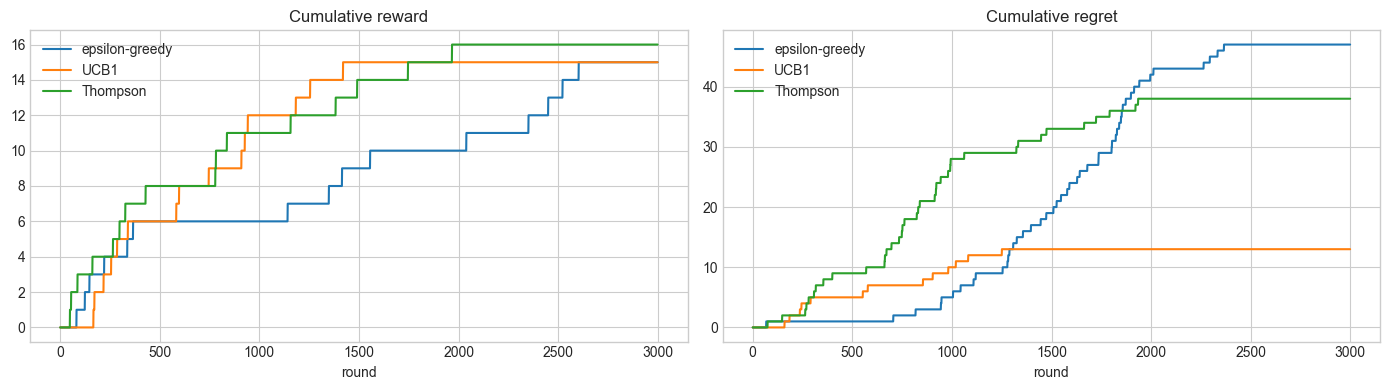

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(eps_cum_reward, label='epsilon-greedy')
axes[0].plot(ucb_cum_reward, label='UCB1')
axes[0].plot(ths_cum_reward, label='Thompson')
axes[0].set_title('Cumulative reward')
axes[0].set_xlabel('round')
axes[0].legend()

axes[1].plot(eps_cum_regret, label='epsilon-greedy')
axes[1].plot(ucb_cum_regret, label='UCB1')
axes[1].plot(ths_cum_regret, label='Thompson')
axes[1].set_title('Cumulative regret')
axes[1].set_xlabel('round')
axes[1].legend()

plt.tight_layout()
plt.show()


The results show that Thompson Sampling achieves the highest cumulative reward, indicating better ability to identify relevant recommendations over time. However, UCB1 achieves the lowest cumulative regret, demonstrating more efficient exploration. Epsilon-greedy performs worst in both metrics, confirming that simple exploration strategies are less effective in this setting.

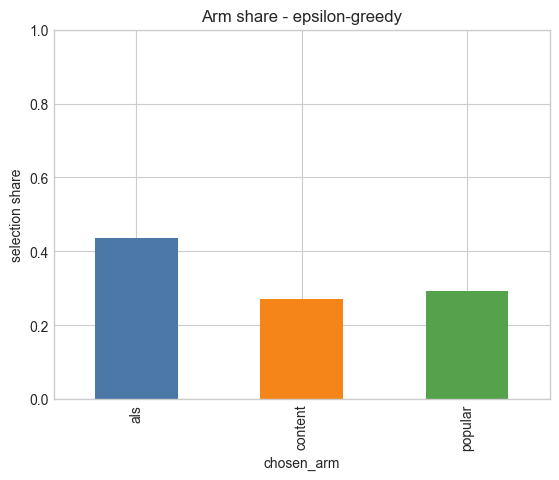

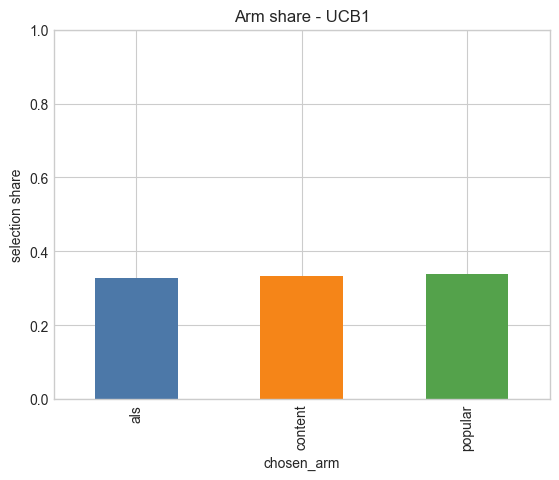

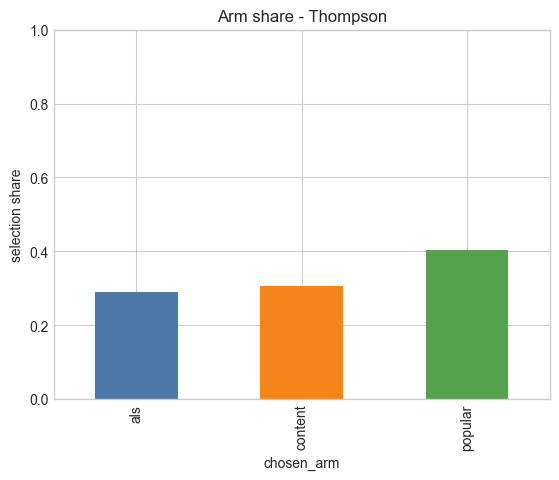

In [71]:
def plot_arm_share(df, title):
    share = df['chosen_arm'].value_counts(normalize=True).sort_index()
    share.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'])
    plt.title(title)
    plt.ylabel('selection share')
    plt.ylim(0, 1)
    plt.show()

plot_arm_share(eps_rounds, 'Arm share - epsilon-greedy')
plot_arm_share(ucb_rounds, 'Arm share - UCB1')
plot_arm_share(ths_rounds, 'Arm share - Thompson')


## 5) Save outputs

In [72]:
results.to_csv(RESULTS_DIR / 'bandit_policy_summary.csv', index=False)
eps_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_epsilon_greedy.csv', index=False)
ucb_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_ucb1.csv', index=False)
ths_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_thompson.csv', index=False)

print('Saved:')
for f in sorted(RESULTS_DIR.glob('bandit_*')):
    print('-', f)


Saved:
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_policy_summary.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_epsilon_greedy.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_thompson.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_ucb1.csv
